In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sim.simulation import DataGen
from sim.sim_plots import plotTermStructure, plotYield
from pricing.pricer import PricerClass
from calibration import Calibration


In [3]:
MATURITIES = np.array([0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30, 40, 50])

trueParams = dict(alpha_r = 1.0547, alpha_m = 0.6358, alpha_l = 0.0165,
                  sigma_m = 109.2/10000, sigma_l = 96.4/10000,
                  rho = 0.212,
                  mu = 10.555/100)

beginningRates = dict(beginning_r = 0.03, beginning_m = 0.04, beginning_l = 0.05)

simulationClass = DataGen(**trueParams, **beginningRates, seed = 43)
truePricerClass = PricerClass(**trueParams)

In [4]:
factorsPath = simulationClass.generatePath(sampleSize = 3000)
factorsPath

array([[0.03      , 0.04      , 0.05      ],
       [0.040547  , 0.03894349, 0.05339791],
       [0.03885578, 0.06007832, 0.04550066],
       ...,
       [0.12182075, 0.1082623 , 0.1158112 ],
       [0.10752065, 0.12274953, 0.1291014 ],
       [0.12358255, 0.11960941, 0.13053977]])

In [5]:
termStructurePath = np.array([truePricerClass.termStructure(maturities=MATURITIES, factors=factorsPath[i]) for i in range(len(factorsPath))])
termStructurePath = pd.DataFrame(termStructurePath, columns = MATURITIES)
termStructurePath['short'] = factorsPath[:, 0]
termStructurePath = termStructurePath[[list(termStructurePath.columns)[-1]] + list(termStructurePath.columns)[:-1]]
termStructurePath

,short,0.5,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,12.0,15.0,20.0,30.0,40.0,50.0
0,0.030000,0.032458,0.034585,0.038006,0.040571,0.042528,0.044053,0.045268,0.046256,0.047074,0.047760,0.048342,0.049265,0.050210,0.050988,0.050622,0.048614,0.045579
1,0.040547,0.040521,0.041030,0.042700,0.044503,0.046119,0.047485,0.048618,0.049559,0.050344,0.051004,0.051562,0.052439,0.053316,0.053981,0.053400,0.051196,0.047982
2,0.038856,0.043257,0.045894,0.048321,0.049032,0.049157,0.049120,0.049070,0.049050,0.049065,0.049108,0.049169,0.049312,0.049499,0.049575,0.048644,0.046471,0.043418
3,0.061239,0.061223,0.060497,0.058285,0.056071,0.054256,0.052875,0.051859,0.051121,0.050588,0.050201,0.049919,0.049554,0.049250,0.048869,0.047561,0.045270,0.042192
4,0.063341,0.056493,0.051859,0.046532,0.044007,0.042807,0.042260,0.042048,0.042012,0.042073,0.042184,0.042320,0.042613,0.043005,0.043380,0.042952,0.041209,0.038534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.126673,0.129666,0.131595,0.133611,0.134370,0.134569,0.134505,0.134308,0.134036,0.133716,0.133360,0.132975,0.132131,0.130707,0.127983,0.121552,0.114276,0.106563
2996,0.141448,0.137233,0.134111,0.129939,0.127373,0.125667,0.124445,0.123506,0.122739,0.122079,0.121485,0.120934,0.119896,0.118386,0.115777,0.109919,0.103328,0.096297
2997,0.121821,0.118970,0.117199,0.115443,0.114808,0.114590,0.114508,0.114448,0.114370,0.114257,0.114109,0.113924,0.113459,0.112553,0.110604,0.105530,0.099438,0.092779
2998,0.107521,0.111057,0.113805,0.117664,0.120112,0.121700,0.122739,0.123413,0.123832,0.124069,0.124169,0.124164,0.123919,0.123140,0.121142,0.115617,0.108950,0.101710


In [6]:
forwardTermStructurePath = np.array([truePricerClass.forwardTermStructure(deltaTau=1, maturities=MATURITIES, factors=factorsPath[i]) for i in range(len(factorsPath))])
forwardTermStructurePath = pd.DataFrame(forwardTermStructurePath, columns = MATURITIES)
forwardTermStructurePath

,0.5,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,12.0,15.0,20.0,30.0,40.0,50.0
0,0.038402,0.041426,0.045701,0.048398,0.050154,0.051345,0.052186,0.052799,0.053250,0.053579,0.053808,0.054017,0.053810,0.052330,0.046292,0.037751,0.028049
1,0.042452,0.044370,0.048111,0.050967,0.052946,0.054287,0.055204,0.055839,0.056281,0.056582,0.056774,0.056897,0.056553,0.054857,0.048435,0.039568,0.029590
2,0.049534,0.050747,0.050455,0.049531,0.048972,0.048821,0.048932,0.049171,0.049450,0.049716,0.049941,0.050222,0.050179,0.048984,0.043455,0.035346,0.026010
3,0.058555,0.056072,0.051643,0.048811,0.047354,0.046778,0.046694,0.046853,0.047109,0.047382,0.047629,0.047971,0.048033,0.047007,0.041779,0.033925,0.024805
4,0.044802,0.041206,0.038956,0.039206,0.040072,0.040987,0.041802,0.042494,0.043071,0.043545,0.043928,0.044449,0.044701,0.043942,0.039180,0.031721,0.022937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.134413,0.135627,0.135888,0.135164,0.134249,0.133324,0.132406,0.131475,0.130513,0.129510,0.128460,0.126217,0.122512,0.115591,0.099931,0.083231,0.066611
2996,0.129014,0.125767,0.122241,0.120549,0.119555,0.118812,0.118138,0.117457,0.116738,0.115969,0.115146,0.113340,0.110259,0.104308,0.090364,0.075119,0.059734
2997,0.114677,0.113687,0.113537,0.113938,0.114178,0.114151,0.113897,0.113472,0.112918,0.112265,0.111531,0.109865,0.106959,0.101271,0.087789,0.072936,0.057882
2998,0.118410,0.121523,0.125009,0.126464,0.126895,0.126779,0.126350,0.125726,0.124971,0.124119,0.123190,0.121144,0.117693,0.111154,0.096169,0.080041,0.063907


### 1. Recovery of $\alpha$

In [138]:
cal = Calibration(termStructurePath= termStructurePath, 
                  forwardTermStructurePath= forwardTermStructurePath,
                  useInputForwards=True,
                  maturities = MATURITIES, 
                  fairly_priced=[2, 10], fairly_priced_fwd= [2, 10], fwd_deltaTau= 1,
                  lossDecayFactor= 0.8)

In [139]:
best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 1.5, 0.01))
best_alpha

alpha_r: 1.0500000000000005, alpha_m: 0.6385365918211211,               alpha_l: 0.0164745090284855, loss: 3.747360568351186e-07,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


{'alpha_r': 1.0500000000000005,
 'alpha_m': 0.6385365918211211,
 'alpha_l': 0.0164745090284855,
 'loss': 3.747360568351186e-07,
 'success': True,
 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'}

In [377]:
avgBiasCollector = dict()
grid = np.arange(0.5, 1.5, 0.01)
results = []
for i in range(100):
    u0 = np.random.uniform(1e-6, 0.8)
    u1 = np.random.uniform(1e-6, 0.8)
    initialGuess = [u0, u1]
    result = cal.calibrateAlphaSecondStep(grid = grid, initialGuess = initialGuess)
    results.append(result)
    

alpha_r: 1.0500000000000005, alpha_m: 0.6365244427736486,               alpha_l: 0.016477179080040327, loss: 9.728498380331545e-08,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
alpha_r: 1.0500000000000005, alpha_m: 0.636524419437813,               alpha_l: 0.016477178386993096, loss: 9.728498455270625e-08,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
alpha_r: 1.0500000000000005, alpha_m: 0.6365244936412868,               alpha_l: 0.016477156990215732, loss: 9.728504440376784e-08,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
alpha_r: 1.0500000000000005, alpha_m: 0.6365267907955994,               alpha_l: 0.016476724212547998, loss: 9.730301200936588e-08,              success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
alpha_r: 1.0500000000000005, alpha_m: 0.6365232428726149,               alpha_l: 0.01647727558194443, loss: 9.728585306967965e-08,

In [398]:
biases = np.array([(x['alpha_r'] - trueParams['alpha_r'], x['alpha_m'] - trueParams['alpha_m'], x['alpha_l'] - trueParams['alpha_l']) for x in results if x['success'] == True])

print('No convergence: \t' ,len([x for x in results if x['success'] == False]))
print('Avg. loss: \t' ,np.mean([x['loss'] for x in results if x['success'] == True]))

biasSummary = pd.DataFrame(np.mean(biases, axis = 0), index = ['alpha_r', 'alpha_m', 'alpha_l'], columns = ['Avg. Bias'])
biasSummary['-2sigma'] = biasSummary['Avg. Bias'] - 2 * np.std(biases, axis = 0) 
biasSummary['+2sigma'] = biasSummary['Avg. Bias'] + 2 * np.std(biases, axis = 0) 
biasSummary

No convergence: 	 0
Avg. loss: 	 1.3487754971681275e-07


,Avg. Bias,-2sigma,+2sigma
alpha_r,-0.003900,-0.011738,0.003938
alpha_m,0.000607,-0.000542,0.001756
alpha_l,-0.000019,-0.000056,0.000018


### 2. Recovery of $\sigma$

In [140]:
cal.modelImpliedVariance(tau = 10, alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = trueParams['sigma_m'], sigma_l = trueParams['sigma_l'], rho = trueParams['rho'])

5.359386376114409e-05

In [141]:
cal.empiricalVariance(tau = 10, alpha_r = best_alpha['alpha_r'])

5.539643837330786e-05

In [142]:
cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], initialGuess = [0.2, 0.2, 0.01])

sigma_m: 0.03204720537918733, sigma_l: 0.00230614250627337, rho: 0.0006911259120460598, loss: 4.571033617640281e-08, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


{'sigma_m': 0.03204720537918733,
 'sigma_l': 0.00230614250627337,
 'rho': 0.0006911259120460598,
 'loss': 4.571033617640281e-08,
 'success': True,
 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'}

In [143]:
cal.calibrateSigmaCov(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], initialGuess = [0.2, 0.2, 0.01])

sigma_m: 0.02602300312062473, sigma_l: 1e-06, rho: -0.06482301018816827, loss: 2.884972118320052e-07, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


{'sigma_m': 0.02602300312062473,
 'sigma_l': 1e-06,
 'rho': -0.06482301018816827,
 'loss': 2.884972118320052e-07,
 'success': True,
 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'}

In [144]:
best_sigma = cal.calibrateSigmaChol(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                    alpha_l = best_alpha['alpha_l'], initialGuess = [-4.6, -4.6, 0.01])

best_sigma

sigma_m: 0.01005146994747245, sigma_l: 0.010516585199856205, rho: -0.29431225415538576, loss: 4.079463987984073e-08, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


{'sigma_m': 0.01005146994747245,
 'sigma_l': 0.010516585199856205,
 'rho': -0.29431225415538576,
 'Sigma_x': array([[ 1.01032048e-04, -3.11109067e-05],
        [-3.11109067e-05,  1.10598564e-04]]),
 'loss': 4.079463987984073e-08,
 'success': True,
 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'}

### 3. Recovery of latent factors and yields, soundness check of how it works

Text(0.5, 0.98, 'Factor recovery with true parameters, from spot rates')

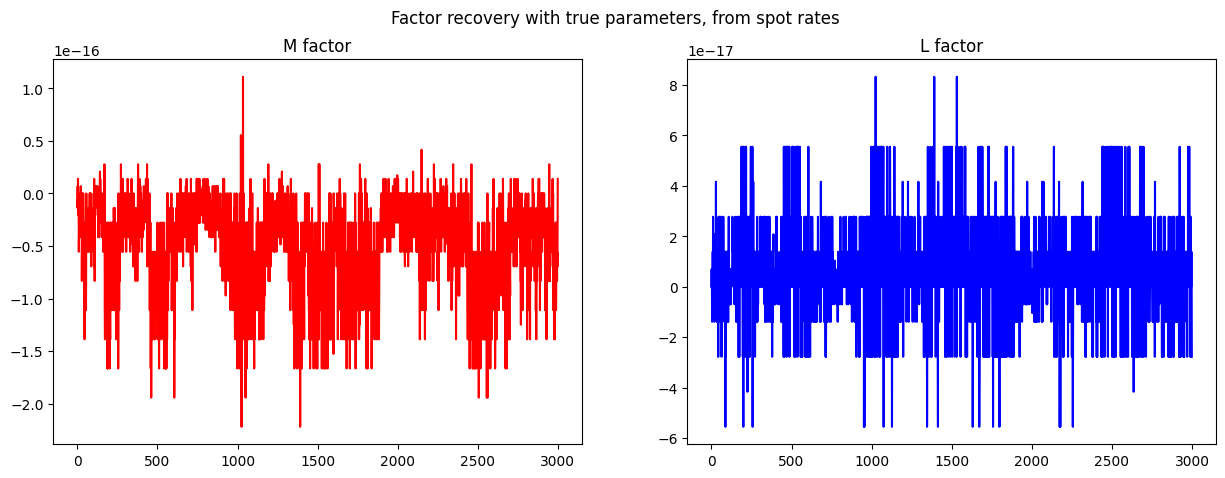

In [157]:
lf = cal.extractLatentFactors(alpha_r = trueParams['alpha_r'], alpha_m = trueParams['alpha_m'], alpha_l = trueParams['alpha_l'], 
                              sigma_m = trueParams['sigma_m'], sigma_l = trueParams['sigma_l'], rho = trueParams['rho'], mu = trueParams['mu'])

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax[0].plot(lf[:, 0] - factorsPath[:, 1], color = 'red')
ax[0].set_title('M factor')
ax[1].plot(lf[:, 1] - factorsPath[:, 2], color = 'blue')
ax[1].set_title('L factor')
fig.suptitle('Factor recovery with true parameters, from spot rates')

Note how if we extract the factors based on the forwards that the class computes from the ZCB term structure, we get errors in the order of $10^{-3}$.

Text(0.5, 0.98, 'Factor recovery with true parameters, from implied fwd rates')

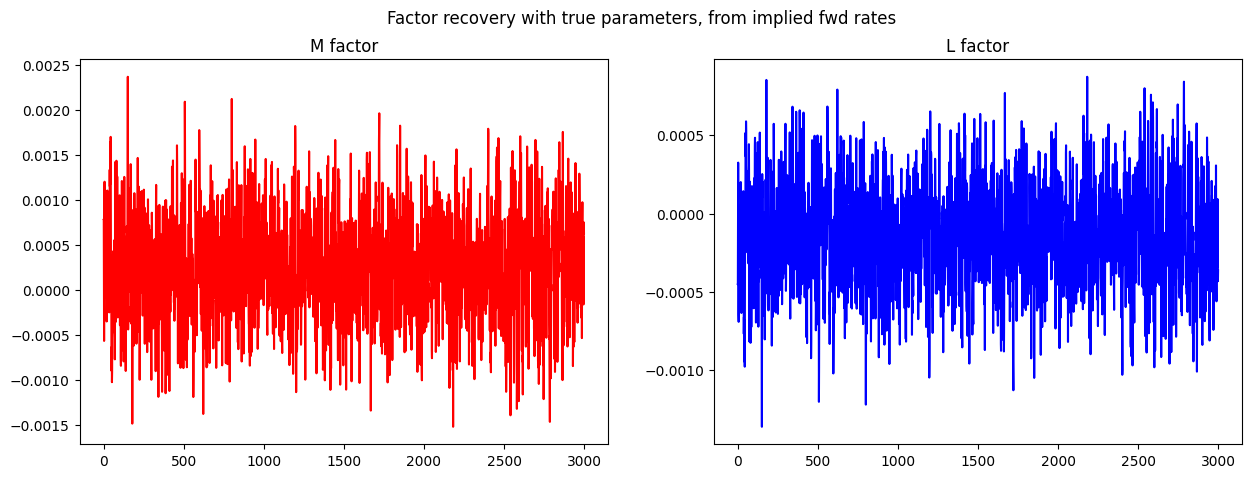

In [156]:
cal.useInputForwards = False

lf = cal.extractLatentFactors_fwd(alpha_r = trueParams['alpha_r'], alpha_m = trueParams['alpha_m'], alpha_l = trueParams['alpha_l'], 
                                  sigma_m = trueParams['sigma_m'], sigma_l = trueParams['sigma_l'], rho = trueParams['rho'], mu = trueParams['mu'])

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax[0].plot(lf[:, 0] - factorsPath[:, 1], color = 'red')
ax[0].set_title('M factor')
ax[1].plot(lf[:, 1] - factorsPath[:, 2], color = 'blue')
ax[1].set_title('L factor')
fig.suptitle('Factor recovery with true parameters, from implied fwd rates')

If we instead extract factors out of the forwards generated from the pricer, we get perfect recovery.

Text(0.5, 0.98, 'Factor recovery with true parameters, from true fwd rates')

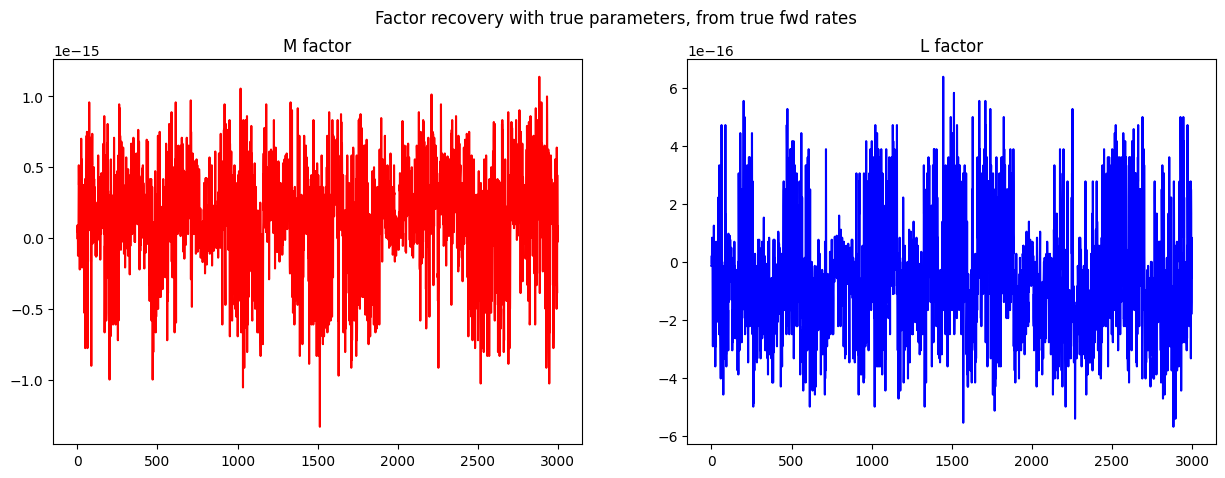

In [155]:
cal.useInputForwards = True

lf = cal.extractLatentFactors_fwd(alpha_r = trueParams['alpha_r'], alpha_m = trueParams['alpha_m'], alpha_l = trueParams['alpha_l'], 
                                  sigma_m = trueParams['sigma_m'], sigma_l = trueParams['sigma_l'], rho = trueParams['rho'], mu = trueParams['mu'])

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax[0].plot(lf[:, 0] - factorsPath[:, 1], color = 'red')
ax[0].set_title('M factor')
ax[1].plot(lf[:, 1] - factorsPath[:, 2], color = 'blue')
ax[1].set_title('L factor')
fig.suptitle('Factor recovery with true parameters, from true fwd rates')

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_2008/2975253422.py:10: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle('Factor recovery with estimated parameters + perfect $\mu$, from spot rates')


Text(0.5, 0.98, 'Factor recovery with estimated parameters + perfect $\\mu$, from spot rates')

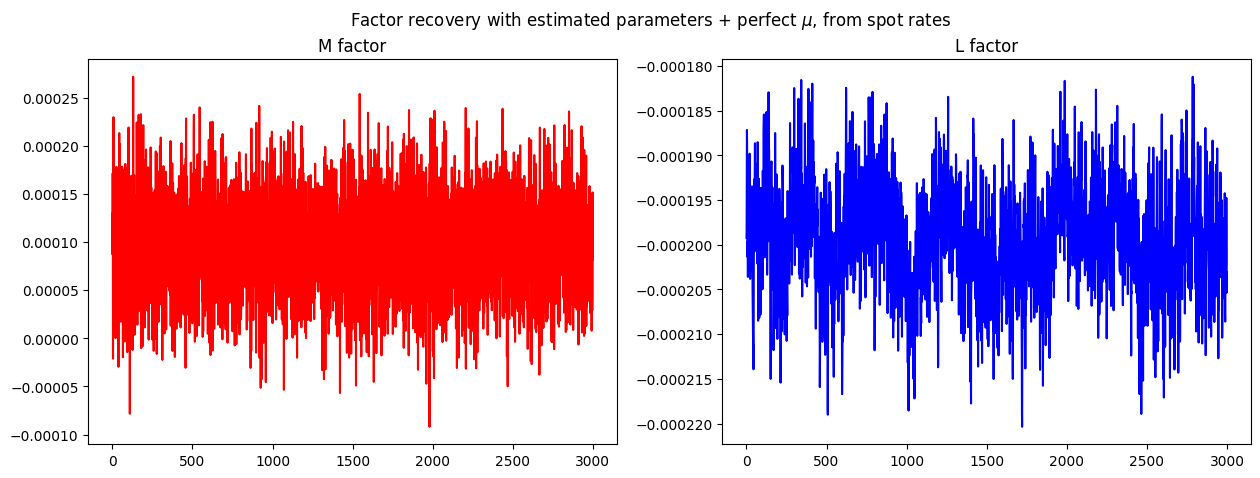

In [154]:
lf = cal.extractLatentFactors(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = trueParams['mu'])

fig, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].plot(lf[:, 0] - factorsPath[:, 1], color = 'red')
ax[0].set_title('M factor')
ax[1].plot(lf[:, 1] - factorsPath[:, 2], color = 'blue')
ax[1].set_title('L factor')
fig.suptitle('Factor recovery with estimated parameters + perfect $\mu$, from spot rates')

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_2008/387111159.py:11: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle('Factor recovery with estimated parameters + perfect $\mu$, from true fwd rates')


Text(0.5, 0.98, 'Factor recovery with estimated parameters + perfect $\\mu$, from true fwd rates')

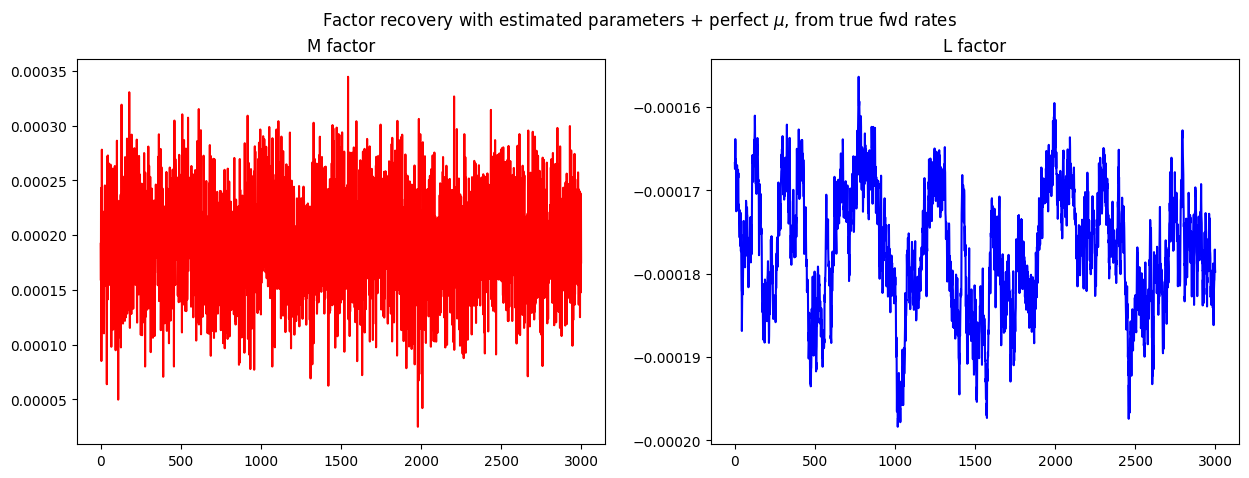

In [161]:
cal.useInputForwards = True
lf = cal.extractLatentFactors_fwd(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = trueParams['mu'])

fig, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].plot(lf[:, 0] - factorsPath[:, 1], color = 'red')
ax[0].set_title('M factor')
ax[1].plot(lf[:, 1] - factorsPath[:, 2], color = 'blue')
ax[1].set_title('L factor')
fig.suptitle('Factor recovery with estimated parameters + perfect $\mu$, from true fwd rates')

In [165]:
fittedTs_spot = cal.fittedYieldsFromMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = trueParams['mu'], 
                         extraction='spot')

fittedTs_fwd = cal.fittedYieldsFromMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = trueParams['mu'], 
                         extraction='fwd')

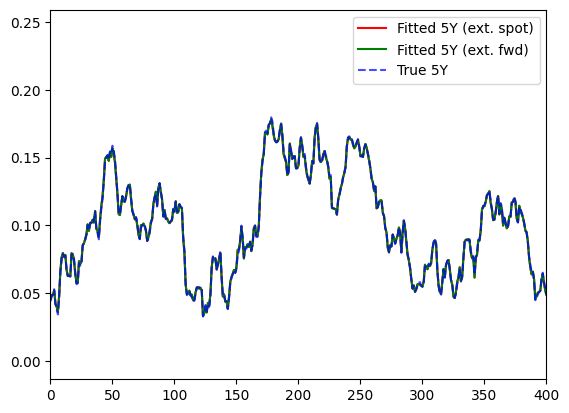

In [167]:
fittedTsDf_spot = pd.DataFrame(fittedTs_spot, index = termStructurePath.index, columns = termStructurePath.columns[:-1])
fittedTsDf_fwd = pd.DataFrame(fittedTs_fwd, index = termStructurePath.index, columns = termStructurePath.columns[:-1])
plt.plot(fittedTsDf_spot[5], color = 'red', label = 'Fitted 5Y (ext. spot)')
plt.plot(fittedTsDf_fwd[5], color = 'green', label = 'Fitted 5Y (ext. fwd)')
plt.plot(termStructurePath[5], color = 'blue', label = 'True 5Y', linestyle = '--', alpha = 0.7)

plt.xlim(0, 400)
plt.legend()
plt.show()



### 4. Recovery of $\mu$ via 2y and 10y ZCB, fit check of all estimated parameters

In [170]:
best_mu_spot = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], 
                         initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'spot')

mu: 0.11346143202778315, loss: 0.0004775500165031074, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


In [180]:
MATURITIES = np.array([0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30, 40, 50])
calParams = dict(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                  sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu_spot['mu'])

fittedPricer = PricerClass(**calParams)
lf = cal.extractLatentFactors(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu_spot['mu'])

In [181]:
estFactorsDf_spot = pd.DataFrame(lf, columns = ['medium', 'long'])
estFactorsDf_spot['short'] = factorsPath[:, 0]
estFactorsDf_spot = estFactorsDf_spot[['short', 'medium', 'long']]
estFactorsDf_spot.iloc[-1]

short     0.123583
medium    0.119973
long      0.129748
Name: 2999, dtype: float64

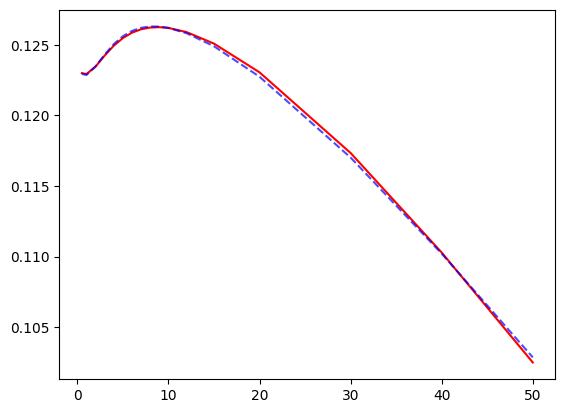

In [182]:
plt.plot(MATURITIES, fittedPricer.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_spot.iloc[-1].values)), color = 'red', label = 'Fitted ts')
plt.plot(MATURITIES, termStructurePath.iloc[-1][1:], color = 'blue', label = 'True ts', linestyle = '--', alpha = 0.7)

### 5. Recovery of $\mu$ via 2y-forward and 10y-forward 1y rates, fit check of all estimated parameters

In [171]:
best_mu_fwd = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], 
                         initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')

mu: 0.11436738967562056, loss: 0.0012091382403765219, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


In [203]:
MATURITIES = np.array([0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30, 40, 50])
cal.useInputForwards = True
calParams = dict(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                  sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu_fwd['mu'])

fittedPricer = PricerClass(**calParams)
lf = cal.extractLatentFactors_fwd(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu_fwd['mu'])

In [204]:
estFactorsDf_fwd = pd.DataFrame(lf, columns = ['medium', 'long'])
estFactorsDf_fwd['short'] = factorsPath[:, 0]
estFactorsDf_fwd = estFactorsDf_fwd[['short', 'medium', 'long']]
estFactorsDf_fwd.iloc[-1]

short     0.123583
medium    0.121662
long      0.129114
Name: 2999, dtype: float64

Do the factor recoveries change that much when we extract with spot or forwards? No.

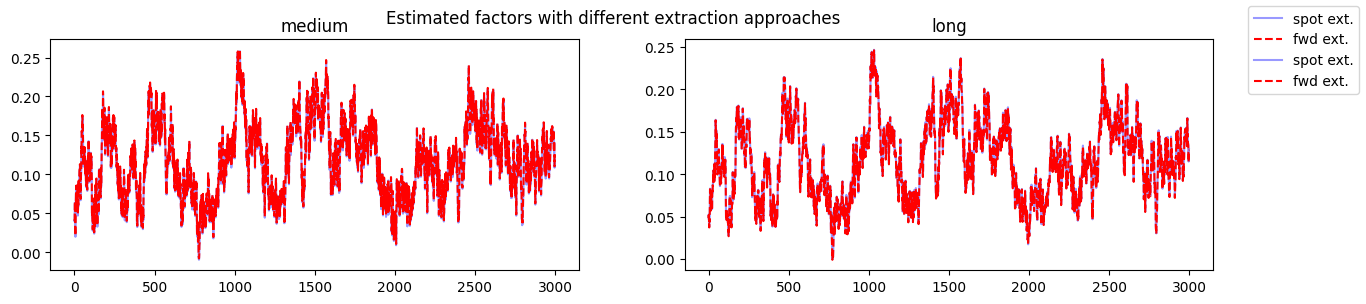

In [205]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 3))
ax = ax.flatten()
for i, name in zip(list(range(0,2)), ['medium', 'long']):
    ax[i].plot(estFactorsDf_spot[name], color = 'blue', label = 'spot ext.', alpha = 0.4)
    ax[i].plot(estFactorsDf_fwd[name], color = 'red', linestyle = '--', label = 'fwd ext.', alpha = 1)
    ax[i].set_title(name)

fig.suptitle('Estimated factors with different extraction approaches')
fig.legend()

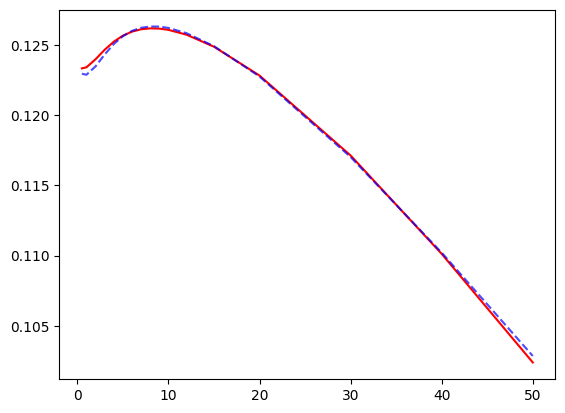

In [206]:
plt.plot(MATURITIES, fittedPricer.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_fwd.iloc[-1].values)), color = 'red', label = 'Fitted ts')
plt.plot(MATURITIES, termStructurePath.iloc[-1][1:], color = 'blue', label = 'True ts', linestyle = '--', alpha = 0.7)

### 6. Risk premia

How does my choice of $\tau,\tau'$ affect my estimate of a risk premium?

In [64]:
curveToday = termStructurePath.iloc[-1, 1:].to_list()

for x,y in zip([x for x in range(13, 49, 2)], [x for x in range(14, 50, 2)]):
    print(f"Tau = {x} and Tau' = {y}:", cal.lambdaFromForwards(tau = x, tauPrime= y, deltaTau= 1, curve = curveToday, **calParams))

Tau = 13 and Tau' = 14: -0.07880480955079634
Tau = 15 and Tau' = 16: -0.11676886791947254
Tau = 17 and Tau' = 18: -0.12299273342676824
Tau = 19 and Tau' = 20: -0.5739034358210248
Tau = 21 and Tau' = 22: -0.18092188315503666
Tau = 23 and Tau' = 24: -0.19042918248660815
Tau = 25 and Tau' = 26: -0.20038253975256848
Tau = 27 and Tau' = 28: -0.21079941786131015
Tau = 29 and Tau' = 30: -0.8680853962066731
Tau = 31 and Tau' = 32: -0.27694344600820714
Tau = 33 and Tau' = 34: -0.29110395097971675
Tau = 35 and Tau' = 36: -0.30590549906660236
Tau = 37 and Tau' = 38: -0.3213724198518337
Tau = 39 and Tau' = 40: -0.8904794899537163
Tau = 41 and Tau' = 42: -0.38272491759134497
Tau = 43 and Tau' = 44: -0.4017490473766483
Tau = 45 and Tau' = 46: -0.42160483557611056
Tau = 47 and Tau' = 48: -0.4423226701743503


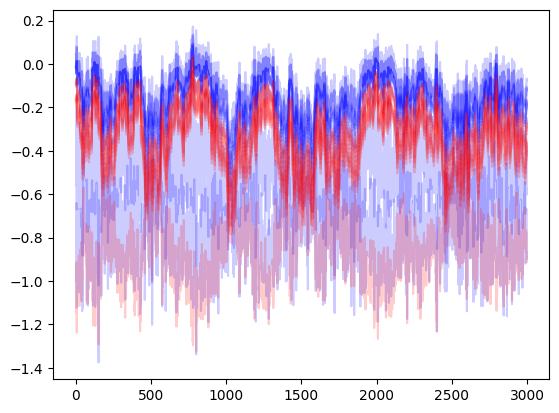

In [75]:
for x,y in zip([x for x in range(13, 49, 2)], [x for x in range(14, 50, 2)]):
    color =  'red' if x > 31 else 'blue'
    plt.plot(cal.lambdaSeriesFromForwards(tau = x, tauPrime = y, deltaTau= 1, **calParams), alpha = 0.2, color = color)

In [93]:
[fittedPricer.amountOfRisk(tau = x, deltaTau=1) for x in MATURITIES]

[0.0009013765249594327,
 0.0022932531027107135,
 0.007146056593043644,
 0.014092409332234409,
 0.022282446851407477,
 0.031094963466973984,
 0.040145204084659235,
 0.04921360433944972,
 0.05818133100657043,
 0.06698704586714951,
 0.07560102826719917,
 0.09221180872982074,
 0.11558555266490997,
 0.15071607343444723,
 0.20879400958595742,
 0.2539725425008753,
 0.2893556361175688]

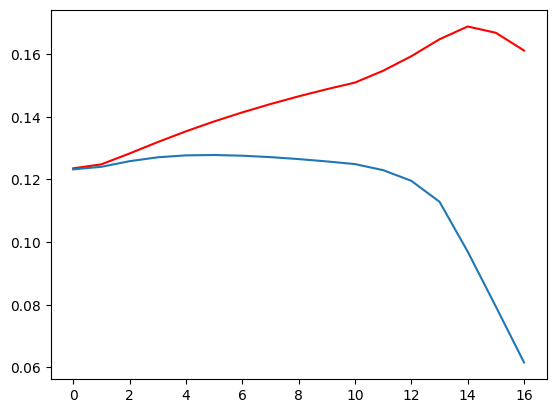

In [ ]:
curveToday = termStructurePath.iloc[-1, 1:].to_list()
lambdaToday = cal.lambdaFromForwards(tau = 14, tauPrime= 15, deltaTau= 1, curve = curveToday, **calParams)
forwardCurveToday = fittedPricer.forwardTermStructure(
    deltaTau=1, maturities=MATURITIES, factors=estFactorsDf.iloc[-1].to_list()
    )

expRatePathToday = forwardCurveToday - [lambdaToday * fittedPricer.amountOfRisk(tau = x, deltaTau=1) for x in MATURITIES]

plt.plot(expRatePathToday, color = 'red')
plt.plot(forwardCurveToday)

### 5. OOS fitting

In [639]:
INSAMPLESPLIT = 2000
cal = Calibration(termStructurePath[:INSAMPLESPLIT], maturities = MATURITIES, fairly_priced=[2, 10])
best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 1.5, 0.01))
best_sigma = cal.calibrateSigmaChol(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                    alpha_l = best_alpha['alpha_l'], initialGuess = [-4.6, -4.6, 0.01])
best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], initialGuess = 0.01)

alpha_r: 1.0500000000000005, alpha_m: 0.6385169596545598,               alpha_l: 0.016456041373188623, loss: 2.5477670668921035e-07,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.010051401977754226, sigma_l: 0.010618418215636185, rho: -0.3225734046903873, loss: 6.450843070486161e-08, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 0.11105615711331251, loss: 0.00015482749377718793, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


In [640]:
MATURITIES = np.array([0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30])
calParams = dict(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                  sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu['mu'])

fittedPricer = PricerClass(**calParams)
lf = cal.extractLatentFactors(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu['mu'])

In [642]:
estFactorsDf = pd.DataFrame(lf, columns = ['medium', 'long'])
estFactorsDf['short'] = factorsPath[:INSAMPLESPLIT, 0]
estFactorsDf = estFactorsDf[['short', 'medium', 'long']]
estFactorsDf.iloc[-1]

short     0.033258
medium    0.028556
long      0.029913
Name: 1999, dtype: float64

In [644]:
cal = Calibration(termStructurePath, maturities = MATURITIES, fairly_priced=[2, 10])
lf_full = cal.extractLatentFactors(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu['mu'])

In [652]:
estFactorsDf_full = pd.DataFrame(lf_full, columns = ['medium', 'long'])
estFactorsDf_full['short'] = factorsPath[:, 0]
estFactorsDf_full = estFactorsDf_full[['short', 'medium', 'long']]
estFactorsDf_full.iloc[-1]

short     0.051333
medium    0.026185
long      0.047505
Name: 2999, dtype: float64

In [669]:
fittedTs_full = [fittedPricer.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full.iloc[i].values)) for i in range(len(lf_full))]
fittedTs_full_df = pd.DataFrame(fittedTs_full, columns = MATURITIES)

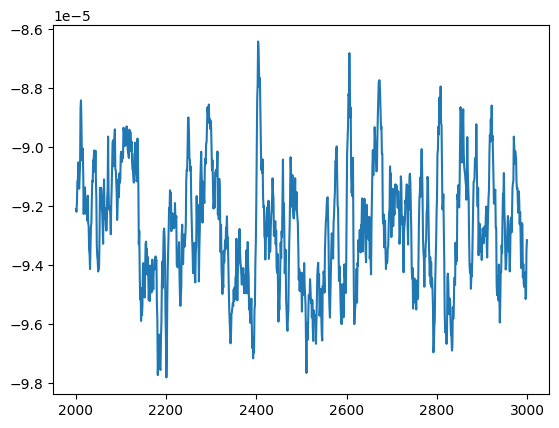

In [678]:
plt.plot(fittedTs_full_df[5][INSAMPLESPLIT+1:] - termStructurePath[5][INSAMPLESPLIT+1:])

### 7. What if we calibrated $\mu,\sigma$ to forwards?

In [16]:
MATURITIES = np.array([x for x in range(1, 31)])

trueParams = dict(alpha_r = 1.0547, alpha_m = 0.6358, alpha_l = 0.0165,
                  sigma_m = 109.2/10000, sigma_l = 96.4/10000,
                  rho = 0.212,
                  mu = 10.555/100)
truePricerClass = PricerClass(**trueParams)

In [17]:
termStructurePath = np.array([truePricerClass.termStructure(maturities=MATURITIES, factors=factorsPath[i]) for i in range(len(factorsPath))])
termStructurePath = pd.DataFrame(termStructurePath, columns = MATURITIES)
termStructurePath['short'] = factorsPath[:, 0]
termStructurePath = termStructurePath[[list(termStructurePath.columns)[-1]] + list(termStructurePath.columns)[:-1]]
termStructurePath

,short,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,0.030000,0.034585,0.038006,0.040571,0.042528,0.044053,0.045268,0.046256,0.047074,0.047760,...,0.051052,0.051090,0.051104,0.051094,0.051064,0.051013,0.050942,0.050853,0.050746,0.050622
1,0.040547,0.041030,0.042700,0.044503,0.046119,0.047485,0.048618,0.049559,0.050344,0.051004,...,0.054022,0.054039,0.054030,0.054000,0.053947,0.053875,0.053783,0.053672,0.053545,0.053400
2,0.038856,0.045894,0.048321,0.049032,0.049157,0.049120,0.049070,0.049050,0.049065,0.049108,...,0.049547,0.049504,0.049446,0.049373,0.049286,0.049185,0.049070,0.048941,0.048799,0.048644
3,0.061239,0.060497,0.058285,0.056071,0.054256,0.052875,0.051859,0.051121,0.050588,0.050201,...,0.048781,0.048684,0.048579,0.048464,0.048339,0.048204,0.048059,0.047903,0.047737,0.047561
4,0.063341,0.051859,0.046532,0.044007,0.042807,0.042260,0.042048,0.042012,0.042073,0.042184,...,0.043407,0.043417,0.043412,0.043391,0.043354,0.043302,0.043236,0.043155,0.043060,0.042952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.126673,0.131595,0.133611,0.134370,0.134569,0.134505,0.134308,0.134036,0.133716,0.133360,...,0.127393,0.126789,0.126173,0.125544,0.124905,0.124254,0.123593,0.122921,0.122241,0.121552
2996,0.141448,0.134111,0.129939,0.127373,0.125667,0.124445,0.123506,0.122739,0.122079,0.121485,...,0.115231,0.114676,0.114111,0.113538,0.112956,0.112365,0.111766,0.111158,0.110542,0.109919
2997,0.121821,0.117199,0.115443,0.114808,0.114590,0.114508,0.114448,0.114370,0.114257,0.114109,...,0.110160,0.109699,0.109224,0.108734,0.108230,0.107713,0.107184,0.106644,0.106092,0.105530
2998,0.107521,0.113805,0.117664,0.120112,0.121700,0.122739,0.123413,0.123832,0.124069,0.124169,...,0.120666,0.120170,0.119655,0.119122,0.118573,0.118008,0.117430,0.116838,0.116233,0.115617


In [55]:
allForwardsPath = {(tau, deltaTau): 
                   np.array([truePricerClass.forwardRate(
                       deltaTau = deltaTau, tau = tau, r=factorsPath[i][0], m = factorsPath[i][1], l = factorsPath[i][2]
                       ) for i in range(len(factorsPath))]
                       ) for tau in MATURITIES for deltaTau in MATURITIES if tau + deltaTau <= max(MATURITIES)}

In [64]:
cal = Calibration(termStructurePath= termStructurePath, 
                  forwardTermStructurePath= forwardTermStructurePath,
                  allForwardsPath= allForwardsPath,
                  useInputForwards=True,
                  maturities = MATURITIES, 
                  fairly_priced=[2, 10], fairly_priced_fwd= [2, 10], fwd_deltaTau= 1,
                  lossDecayFactor= 0.8)